# Radar tutorial 2 — pre-process and merge all sensors with MRMS

**What you'll learn:** how each sensor is brought to a common hourly grid, and how
`RU.merge_event()` builds one tidy table with every sensor next to the radar value at
its location.

| network | raw data | pre-processing to hourly mm (hour-ending, UTC) |
|---|---|---|
| **ASOS** (5 airports) | 1-min gauge + present-weather code | heated-gauge melt QC (tutorial `asos_gauge_melt_qc`); hour NaN if < 90 % of minutes |
| **WU PWS** (80 stations) | 5 min / 15 min / 1 h | station QC drops; hour NaN if < 80 % of samples |
| **NY Mesonet** (4) | 5-min weighing gauge | hour NaN if < 80 % of samples |
| **CML** (120 sublinks ≥ 20 GHz) | 10-min attenuation (dB) | failure samples dropped → ITU-R P.838 power law → hourly mean rate; NaN if < 5 of 6 samples |
| **MRMS** | hourly QPE grids (Pass 2 and radar-only) | value in the gauge's cell, or mean along the CML path |

A gap is always NaN, never 0 mm. **Data:** full-period study files in
`dataset/raw/full/outputs/` (local) and the MRMS cache from tutorial 1.

In [1]:
import sys, warnings
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
pd.set_option('display.width', 200, 'display.max_columns', 30)

REPO_ROOT = Path('..').resolve()
sys.path.insert(0, str(REPO_ROOT / 'src'))
from fetch_data.mrms import MRMSClient, NYC, PRODUCTS, PRECIP_FLAG, event_accumulation
from analysis import radar_utils as RU

## §1. Load every sensor (≈ 2 min: the PWS file is large)

In [2]:
networks, cml, ghcn = RU.load_sensors()
events = RU.load_event_catalog()
events[['event', 'cls', 'start', 'end', 'ghcn_mm', 'ghcn_snow_cm']]

  ASOS         5 stations
  WU PWS      80 stations
  Mesonet      4 stations
  CML        290 sublinks (120 ≥ 20 GHz)
  GHCN         4 stations (daily)


,event,cls,start,end,ghcn_mm,ghcn_snow_cm
0,2026-02-22_snow,snow,2026-02-22 11:50:00,2026-02-24 03:20:00,49.100,55.350
1,2026-01-25_snow,snow,2026-01-25 09:40:00,2026-01-27 07:40:00,35.425,27.700
2,2025-12-26_snow,snow,2025-12-26 21:40:00,2025-12-27 19:10:00,11.725,10.725
3,2024-02-17_snow,snow,2024-02-17 04:40:00,2024-02-17 18:50:00,6.800,9.975
4,2024-02-13_snow,snow,2024-02-13 04:10:00,2024-02-13 18:10:00,16.775,9.900
5,2024-03-23_rain,rain,2024-03-23 00:40:00,2024-03-23 22:20:00,84.825,0.000
6,2024-04-01_rain,rain,2024-04-01 12:40:00,2024-04-04 15:10:00,70.050,0.000
7,2023-12-17_rain,rain,2023-12-17 18:00:00,2023-12-18 19:30:00,60.750,0.000
8,2024-08-06_rain,rain,2024-08-06 18:40:00,2024-08-10 05:30:00,59.975,0.000
9,2023-11-21_rain,rain,2023-11-21 14:30:00,2023-11-22 12:20:00,53.025,0.000


## §2. Pre-processing, one sensor type at a time

Each helper returns a (time × sensor) table of hourly mm for the event window.

In [3]:
EVENT = events.iloc[5]          # 2024-03-23_rain, the wettest rain event
asos_h = RU.gauge_hourly(networks['ASOS'], EVENT.start, EVENT.end)
cml_h = RU.cml_hourly_rain(cml, EVENT.start, EVENT.end, baseline='att_drymed')
print('ASOS hourly (mm):'); display(asos_h.head(8).round(2))
print(f'CML: {cml_h.shape[1]} sublinks, {cml_h.notna().mean().mean():.0%} valid link-hours')

ASOS hourly (mm):


,EWR,JFK,LGA,NYC,TEB
2024-03-23 01:00:00,0.0,0.00,0.00,0.00,0.00
2024-03-23 02:00:00,0.0,0.00,0.00,0.00,0.00
2024-03-23 03:00:00,0.0,0.00,0.00,0.00,0.00
2024-03-23 04:00:00,0.0,0.00,0.00,0.00,0.00
2024-03-23 05:00:00,0.0,0.00,0.00,0.00,0.00
2024-03-23 06:00:00,0.0,0.00,0.00,0.00,0.00
2024-03-23 07:00:00,NaN,0.00,0.25,0.25,0.76
2024-03-23 08:00:00,NaN,0.76,0.25,0.00,0.25


CML: 120 sublinks, 31% valid link-hours


## §3. Merge one event

Columns: `event, cls, time, network, sensor_id, lat, lon, sensor_mm, radar_mm, radar_only_mm`
(`radar_mm` = gauge-corrected Pass 2, `radar_only_mm` = radar only).

In [4]:
merged = RU.merge_event(EVENT, networks, cml)
display(merged.sample(5, random_state=0))
merged.groupby('network').agg(sensors=('sensor_id', 'nunique'),
                              valid_hours=('sensor_mm', lambda x: f'{x.notna().mean():.0%}'),
                              sensor_total_mm=('sensor_mm', 'sum'), radar_total_mm=('radar_mm', 'sum'))

,event,cls,time,network,sensor_id,lat,lon,sensor_mm,radar_mm,radar_only_mm
302,2024-03-23_rain,rain,2024-03-23 04:00:00,WU PWS,KNYNEWYO1127,40.648000,-73.887000,0.000000,0.000000,0.000000
3910,2024-03-23_rain,rain,2024-03-23 01:00:00,CML,212::sublink_1,40.685238,-73.940033,NaN,0.000000,0.000000
3049,2024-03-23_rain,rain,2024-03-23 14:00:00,CML,131::sublink_3,40.720596,-73.969238,6.171631,5.392308,3.684616
2243,2024-03-23_rain,rain,2024-03-23 13:00:00,CML,24::sublink_4,40.652756,-74.002960,0.745249,4.466667,2.833333
304,2024-03-23_rain,rain,2024-03-23 06:00:00,WU PWS,KNYNEWYO1127,40.648000,-73.887000,0.000000,0.000000,0.000000


,sensors,valid_hours,sensor_total_mm,radar_total_mm
network,,,,
ASOS,5,85%,344.170000,364.700012
CML,120,31%,3976.139972,8809.025391
Mesonet,4,100%,348.070000,316.799988
WU PWS,67,96%,4538.218106,5021.399902


## §4. Look at it

The map puts every gauge on the radar's color scale, so disagreement shows as a color
mismatch. The time series compare each network's mean with MRMS at the same locations.

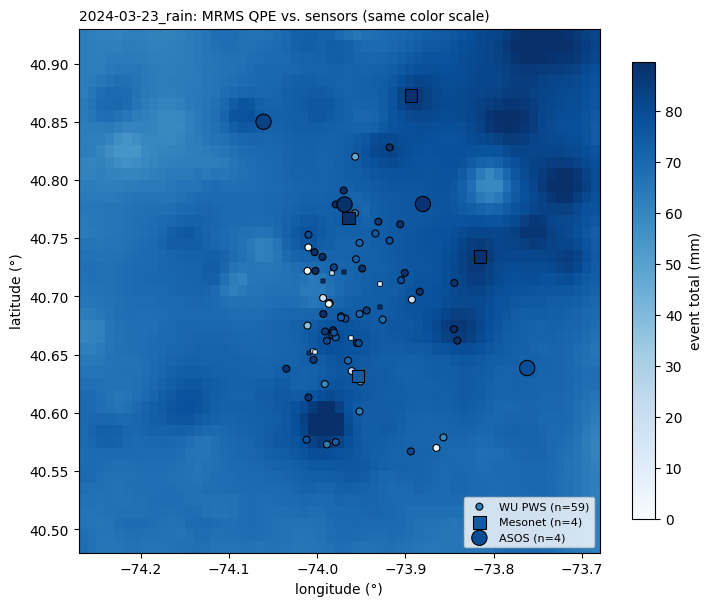

In [5]:
RU.plot_event_map(EVENT, merged);

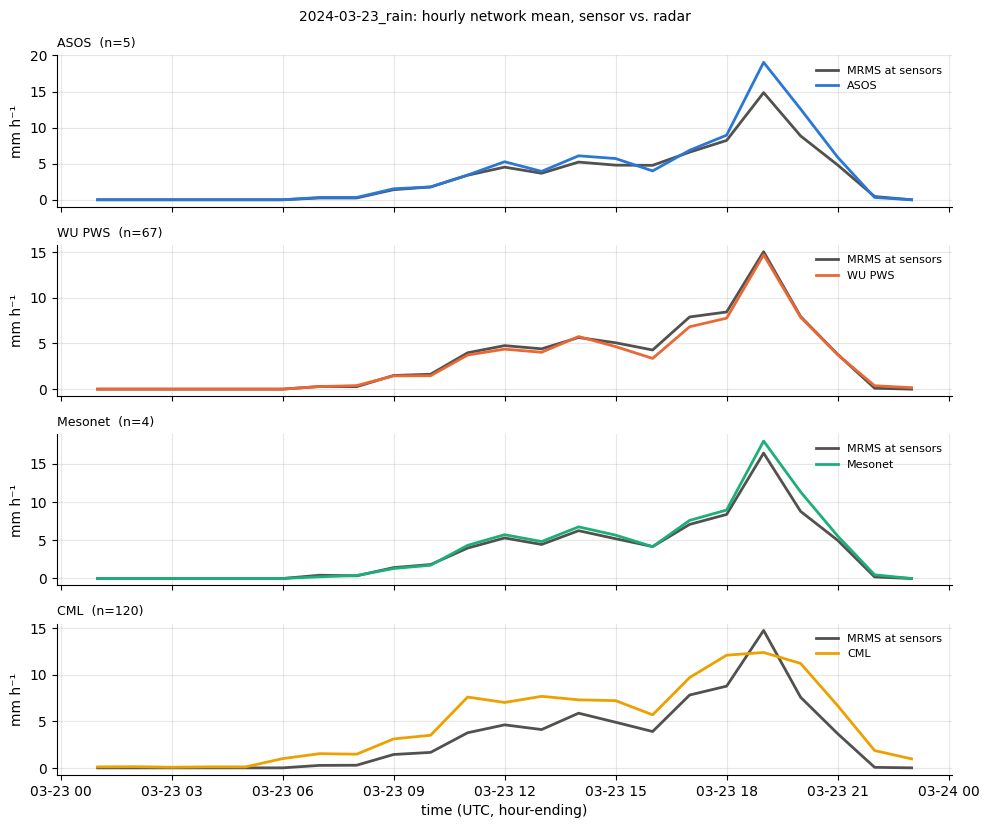

In [6]:
RU.plot_event_timeseries(merged, EVENT.event);

## §5. A snow event, for contrast

The largest snowstorm (2026-02-22 blizzard). Unheated PWS gauges catch almost nothing
in snow, the ASOS 1-min record has an outage (only JFK complete), the Mesonet weighing
gauges track the radar, and CML attenuation in wet snow exceeds what the rain power law
expects.

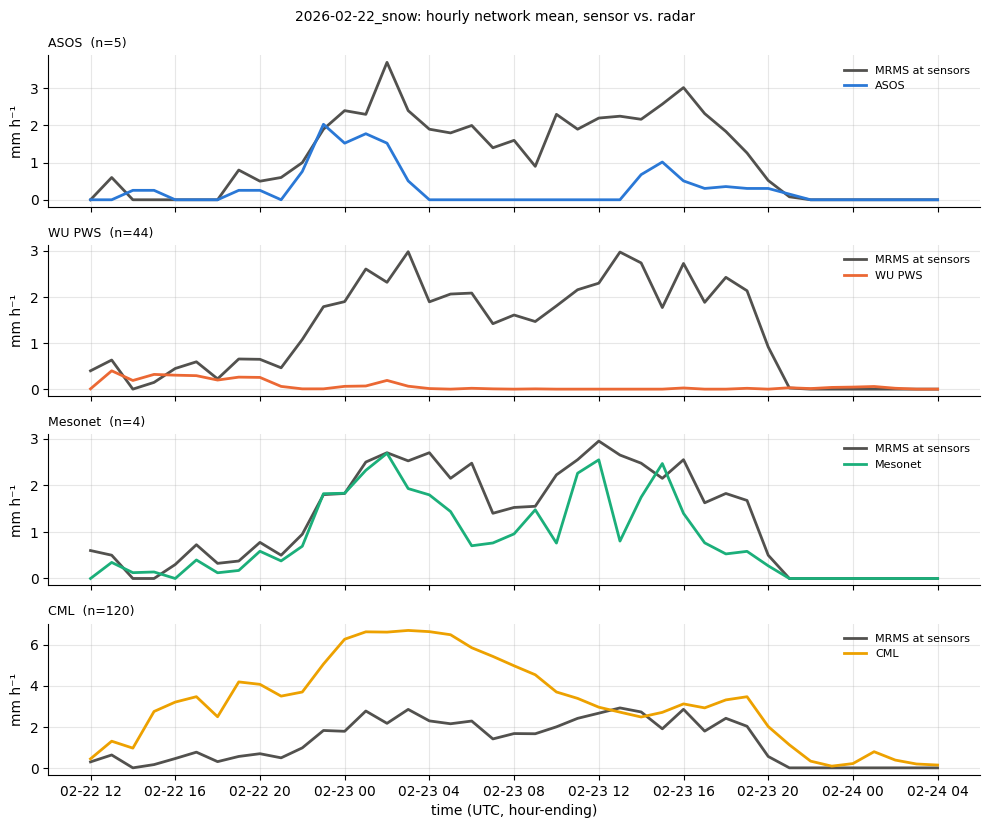

In [7]:
SNOW = events.iloc[0]
merged_snow = RU.merge_event(SNOW, networks, cml)
RU.plot_event_timeseries(merged_snow, SNOW.event);

**Next:** [radar tutorial 3](radar_03_compare_sensors.ipynb) — scores over all 15 events.